# **Base Model Notebook**

### **Wikiart Project**

**Group x:**\
**Afonso Hermenegildo** - 20221958 | **Lara Santos** - 20221823 | **Marco Martins** - 20221951 | **André Nicolau** - 20221918

The goal of this notebook is to build a model from scratch and identify key components and insights that will be useful for developing more complex models.

---

# Table of Contents

1. [First Model](#section-1) 
2. [First Model with Adam](#section-2)  
3. [Base Model with Augmentations and Dropout](#section-3)  
4. [Base Model with GlobalAveragePooling2D](#section-4)  
5. [Base Model Extended with more Convolutions](#section-5)
6. [Base Model with Batch Normalization](#section-6)
8. [Base Model Deeper Classification head](#section-7)
9. [Experimenting different image sizes in the Base Model](#section-8)

---

### Imports

In [128]:
import numpy as np
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, Sequential
from keras.utils import image_dataset_from_directory

# model building imports
from keras import Model, Sequential, Input
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling, RandAugment, GlobalAveragePooling2D, GlobalMaxPool2D, Dropout, RandomRotation, RandomFlip, BatchNormalization, Activation
from keras.optimizers import SGD, Adam
from keras.losses import CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy, AUC, F1Score
from keras.callbacks import EarlyStopping

#Model Class
from keras import Model

#Import our custom augmentations
from augmentation import (
    augmentation_conservative,
    augmentation_mild,
    augmentation_moderate,
    augmentation_moderate_plus,
    augmentation_aggressive,
    augmentation_moderate_noise,
)

#Import Plot Function
from src.utils import plot_model_history

In [129]:
Train_Path = "Data/Train"
Validation_Path = "Data/Validation"

Input_shape = (128,128,3) #We will use 124 x 124 just because we are testing and we want the training to be faster
Batch_size = 64

We will define our evaluation metrics now to avoid redefining them for each model. We will use accuracy, AUC, and macro F1 score, with F1 score being the primary metric due to the imbalanced nature of the dataset.

In [130]:

# metrics
categorical_accuracy = CategoricalAccuracy(name="accuracy")
auc = AUC(name="auc")
f1_score = F1Score(average="macro", name="f1_score")
metrics = [categorical_accuracy, auc, f1_score]

Importing the Train and Validation set

In [131]:
train_df = image_dataset_from_directory(
    Train_Path,
    label_mode="categorical",
    interpolation="bilinear",
    image_size= (128,128),
    batch_size=Batch_size,
    seed=42
)

Found 9329 files belonging to 23 classes.


In [132]:
val_df = image_dataset_from_directory(
    Validation_Path,
    label_mode="categorical",
    interpolation="bilinear",
    image_size= (128,128),
    batch_size=Batch_size,
    seed=42,
)

Found 1999 files belonging to 23 classes.


<a id="section-1"></a>

## **<font color='#ffffffff'> First Model**
 <font>

In [133]:
class First_Model(Model):
    """
    A First model, with a very simple arquitecture that we can build on.
    It has 2 convolutional Blocks with 2 Max Pooling layers, a Flatten layer and 2 Dense Layers

    """
    #Initialization
    def __init__(self):
        super().__init__(name="First_Model")

        self.n_classes = 23
        self.Rescaling = Rescaling(1./255)

        #First Convolutional Block
        self.Conv1 = Conv2D(
            filters=24,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_1"
        )

        #First Pooling Layer
        self.max_pool_layer_1 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_1"
        )


        #Second Convolutional Block
        self.Conv2 = Conv2D(
            filters=24,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_2"
        )

        #Second Pooling Layer
        self.max_pool_layer_2 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_2"
        )

        self.Flatten_layer = Flatten()
        self.Dense_1 = Dense(100, activation="relu")
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)  
        x = self.Conv1(x)
        x = self.max_pool_layer_1(x)
        x = self.Conv2(x)
        x = self.max_pool_layer_2(x)                               
        x = self.Flatten_layer(x)                                       
        x = self.Dense_1(x)
        x = self.Dense_2(x)

        return x

In [134]:
#Get the summary of the model

first_model = First_Model()
inputs = Input(shape=Input_shape)
_ = first_model.call(inputs)
first_model.summary()

Model: "First_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_18 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 126, 126, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ (None, 63, 63, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 61, 61, 24)     │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ (None, 30, 30, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 21600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 100)            │     2,160,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,168,303 (8.27 MB)

 Trainable params: 2,168,303 (8.27 MB)

 Non-trainable params: 0 (0.00 B)

In [135]:
#Defining the optimizer, the loss and the number of epochs

optimizer = SGD(learning_rate=0.01, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs = 20

In [136]:
first_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [137]:
first_model_results = first_model.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)


Epoch 1/20


I0000 00:00:1777028246.209139   62653 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_933826__.47


143/146 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0929 - auc: 0.6073 - f1_score: 0.0208 - loss: 3.0577

I0000 00:00:1777028250.429169   62643 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_933826__.47


146/146 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.1120 - auc: 0.6283 - f1_score: 0.0263 - loss: 3.0231 - val_accuracy: 0.1071 - val_auc: 0.6388 - val_f1_score: 0.0174 - val_loss: 3.0190
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.1585 - auc: 0.6706 - f1_score: 0.0465 - loss: 2.9333 - val_accuracy: 0.1206 - val_auc: 0.6783 - val_f1_score: 0.0323 - val_loss: 2.9756
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.1794 - auc: 0.7135 - f1_score: 0.0614 - loss: 2.8280 - val_accuracy: 0.1786 - val_auc: 0.7163 - val_f1_score: 0.0598 - val_loss: 2.8177
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.1978 - auc: 0.7469 - f1_score: 0.0907 - loss: 2.7336 - val_accuracy: 0.1996 - val_auc: 0.7412 - val_f1_score: 0.1112 - val_loss: 2.7490
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.2196 - auc: 0.7703 - f1_score: 0.1295 - loss: 2.6519 - val_accuracy: 0.1986 - val_auc: 0.7609 - val_f1_score: 0.1149 - val_loss: 2.6

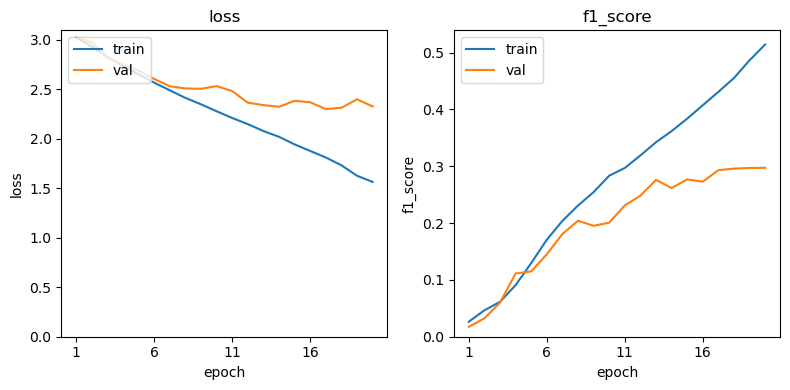

In [138]:
plot_model_history(first_model_results, ["loss", "f1_score"])

The results were as expected, the f1 score was not the best in train and val even with 20 epochs. The model also overfitted a lot, in the last 3 epochs the models could not reduse loss.

In the next step in order to try to increase performance and for the model to converge faster, we decided to switch the optimizer to Adam.

<a id="section-2"></a>

## **<font color='#ffffffff'> First Model with Adam**
 <font>



In [139]:
first_model_adam = First_Model()


In [140]:
#We will decrease the learning rate because Adam is much more sensitive than SGD
optimizer= Adam(learning_rate=0.001, name="optimizer")

In [141]:
first_model_adam.compile(optimizer=optimizer,loss=loss,metrics=metrics)

In [142]:
first_model_adam_results = first_model_adam.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/20


I0000 00:00:1777028319.880516   62653 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_961442__.47


142/146 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2234 - auc: 0.7495 - f1_score: 0.1779 - loss: 2.9613

I0000 00:00:1777028324.135858   62658 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_961442__.47


146/146 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.2234 - auc: 0.7532 - f1_score: 0.1573 - loss: 2.7652 - val_accuracy: 0.2671 - val_auc: 0.7985 - val_f1_score: 0.1783 - val_loss: 2.5257
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.3170 - auc: 0.8361 - f1_score: 0.2589 - loss: 2.3232 - val_accuracy: 0.3212 - val_auc: 0.8346 - val_f1_score: 0.2584 - val_loss: 2.3371
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.4144 - auc: 0.8893 - f1_score: 0.3754 - loss: 1.9814 - val_accuracy: 0.3422 - val_auc: 0.8468 - val_f1_score: 0.2809 - val_loss: 2.2651
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5174 - auc: 0.9270 - f1_score: 0.4884 - loss: 1.6410 - val_accuracy: 0.3352 - val_auc: 0.8403 - val_f1_score: 0.2811 - val_loss: 2.3845
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.6277 - auc: 0.9576 - f1_score: 0.6118 - loss: 1.2652 - val_accuracy: 0.3447 - val_auc: 0.8338 - val_f1_score: 0.2948 - val_loss: 2.4

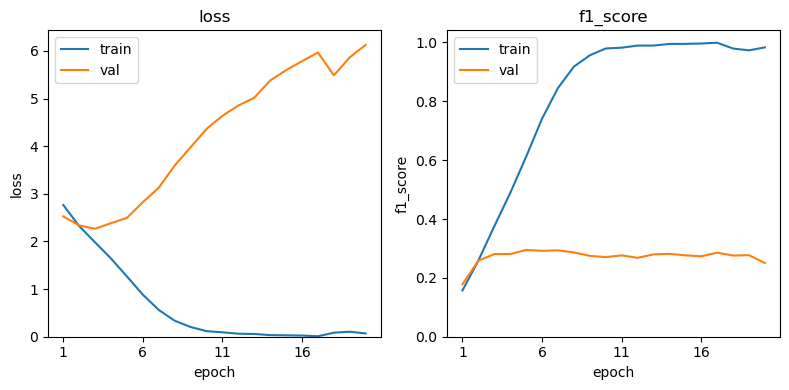

In [143]:
plot_model_history(first_model_adam_results, ["loss", "f1_score"])

The performance of the model generaly improved, and the model converged ultra fast, but we have a lot of over fitting, the scores are very high in the training set and very bad in the validation data set, so we have to do something about it.

In the next setp we will try adding augmentations and drop out in order to reduce overfitting

<a id="section-3"></a>

## **<font color='#ffffffff'> Base model with Augmentations and Dropout**
 <font>


In [144]:
class Augmented_Model(Model):
    """
    Using augmentation techniques and dropout to reduce overfitting.

    """
    #Initialization
    def __init__(self):
        super().__init__(name="Augmented_Model")

        self.n_classes = 23
        self.Rescaling = Rescaling(1./255)
        self.augmentation_layer = augmentation_moderate

        #First Convolutional Block
        self.Conv1 = Conv2D(
            filters=24,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_1"
        )

        #First Pooling Layer
        self.max_pool_layer_1 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_1"
        )


        #Second Convolutional Block
        self.Conv2 = Conv2D(
            filters=24,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_2"
        )

        #Second Pooling Layer
        self.max_pool_layer_2 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_2"
        )

        self.Flatten_layer = Flatten()
        self.Dense_1 = Dense(100, activation="relu")
        self.Drop_out =Dropout(rate=0.2)
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)  
        x = self.augmentation_layer(x)
        x = self.Conv1(x)
        x = self.max_pool_layer_1(x)
        x = self.Conv2(x)
        x = self.max_pool_layer_2(x)                               
        x = self.Flatten_layer(x)                                       
        x = self.Dense_1(x)
        x = self.Drop_out(x)
        x = self.Dense_2(x)

        return x

In [145]:
#Get the summary of the model

Augmented_Model = Augmented_Model()
inputs = Input(shape=Input_shape)
_ = Augmented_Model.call(inputs)
Augmented_Model.summary()

Model: "Augmented_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_20 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate           │ (None, 128, 128, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 126, 126, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ (None, 63, 63, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 61, 61, 24)     │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ (None, 30, 30, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 21600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 100)            │     2,160,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,168,303 (8.27 MB)

 Trainable params: 2,168,303 (8.27 MB)

 Non-trainable params: 0 (0.00 B)

In [146]:
optimizer = Adam(learning_rate=0.001, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs = 20

In [147]:
Augmented_Model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [148]:
Augmented_Model_results = Augmented_Model.fit(
    train_df,
    validation_data= val_df,
    epochs=epochs
)

Epoch 1/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.1567 - auc: 0.6653 - f1_score: 0.1018 - loss: 2.9986 - val_accuracy: 0.1581 - val_auc: 0.7103 - val_f1_score: 0.0937 - val_loss: 2.8480
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.2071 - auc: 0.7471 - f1_score: 0.1286 - loss: 2.7257 - val_accuracy: 0.2126 - val_auc: 0.7570 - val_f1_score: 0.1361 - val_loss: 2.6901
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.2565 - auc: 0.7952 - f1_score: 0.1812 - loss: 2.5352 - val_accuracy: 0.2611 - val_auc: 0.7955 - val_f1_score: 0.1963 - val_loss: 2.5352
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.2906 - auc: 0.8242 - f1_score: 0.2197 - loss: 2.3923 - val_accuracy: 0.2756 - val_auc: 0.8101 - val_f1_score: 0.2168 - val_loss: 2.4658
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.3095 - auc: 0.8373 - f1_score: 0.2427 - loss: 2.3211 - val_accuracy: 0.2936 - val_auc: 0.8249 - val_f1_score: 0.2419 - va

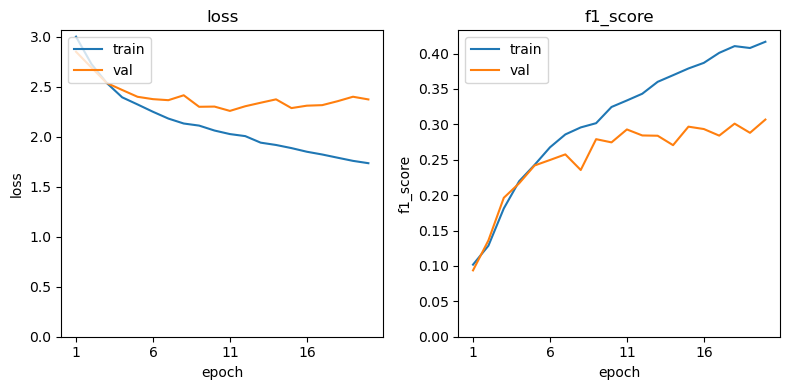

In [149]:
plot_model_history(Augmented_Model_results, ["loss", "f1_score"])


After looking at the plots, we can see that we reduced the overfitting as me wanted, so we will hold the augmentations and the dropout for the future models, but there is still room from improvement.
We spotted that we have a lot of parameters because we are using flatten and this can be another cause for overfitting.

Next we will switch Flatten to GlobalaveragePooling2D to resolve this issue.

<a id="section-4"></a>

## **<font color='#ffffffff'> Base Model with GlobalAveragePooling2D**
 <font>


In [150]:
class Globalaveragepooling_Model(Model):
    """
    Switching Flatten to Globalaveragepooling to reduce the number of parameters

    """
    #Initialization
    def __init__(self):
        super().__init__(name="Globalaveragepooling_Model")

        self.n_classes = 23
        self.Rescaling = Rescaling(1./255)
        self.augmentation_layer = augmentation_moderate

        #First Convolutional Block
        self.Conv1 = Conv2D(
            filters=24,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_1"
        )

        #First Pooling Layer
        self.max_pool_layer_1 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_1"
        )


        #Second Convolutional Block
        self.Conv2 = Conv2D(
            filters=24,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_2"
        )

        #Second Pooling Layer
        self.max_pool_layer_2 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_2"
        )

        self.Globalaveragepooling_layer = GlobalAveragePooling2D()
        self.Dense_1 = Dense(100, activation="relu")
        self.Drop_out =Dropout(rate=0.2)
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)  
        x = self.augmentation_layer(x)
        x = self.Conv1(x)
        x = self.max_pool_layer_1(x)
        x = self.Conv2(x)
        x = self.max_pool_layer_2(x)                               
        x = self.Globalaveragepooling_layer(x)                                     
        x = self.Dense_1(x)
        x = self.Drop_out(x)
        x = self.Dense_2(x)

        return x

In [151]:
Globalaveragepooling_Model = Globalaveragepooling_Model()
inputs = Input(shape=Input_shape)
_ = Globalaveragepooling_Model.call(inputs)
Globalaveragepooling_Model.summary()

Model: "Globalaveragepooling_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_21 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate           │ (None, 128, 128, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 126, 126, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ (None, 63, 63, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 61, 61, 24)     │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ (None, 30, 30, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_14     │ (None, 24)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 100)            │         2,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,703 (41.81 KB)

 Trainable params: 10,703 (41.81 KB)

 Non-trainable params: 0 (0.00 B)

Our total number of parameters decrease from around 2 000 000 to 10 000

In [152]:
optimizer =Adam(learning_rate=0.001, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs = 20

In [153]:
Globalaveragepooling_Model.compile(loss=loss, optimizer=optimizer, metrics=metrics)

In [154]:
Globalaveragepooling_Model_results =Globalaveragepooling_Model.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.1649 - auc: 0.6848 - f1_score: 0.1067 - loss: 3.0021 - val_accuracy: 0.1321 - val_auc: 0.6762 - val_f1_score: 0.0276 - val_loss: 2.9299
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.1625 - auc: 0.7006 - f1_score: 0.0532 - loss: 2.8659 - val_accuracy: 0.1636 - val_auc: 0.7062 - val_f1_score: 0.0543 - val_loss: 2.8525
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.1965 - auc: 0.7318 - f1_score: 0.0794 - loss: 2.7698 - val_accuracy: 0.1861 - val_auc: 0.7336 - val_f1_score: 0.0841 - val_loss: 2.7691
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.2116 - auc: 0.7540 - f1_score: 0.1047 - loss: 2.6981 - val_accuracy: 0.1956 - val_auc: 0.7454 - val_f1_score: 0.0996 - val_loss: 2.7301
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.2235 - auc: 0.7662 - f1_score: 0.1180 - loss: 2.6526 - val_accuracy: 0.2181 - val_auc: 0.7593 - val_f1_score: 0.1151 - va

We ran this model for 20 epochs, and the results were promising. The metrics improved and the model did not show signs of overfitting. However, it had not yet converged, so we will train it for for 20 epochs more.

Results of the first 20 epochs

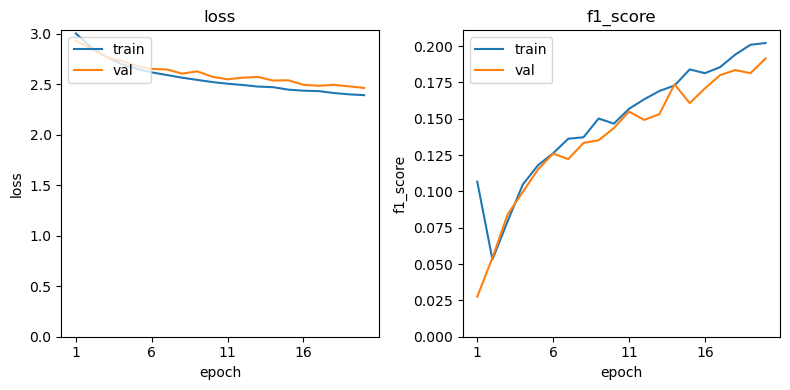

In [155]:

plot_model_history(Globalaveragepooling_Model_results, ["loss", "f1_score"])

In [156]:
Globalaveragepooling_Model_results2 =Globalaveragepooling_Model.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.2955 - auc: 0.8284 - f1_score: 0.2108 - loss: 2.3783 - val_accuracy: 0.2811 - val_auc: 0.8170 - val_f1_score: 0.2005 - val_loss: 2.4494
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.2999 - auc: 0.8320 - f1_score: 0.2135 - loss: 2.3615 - val_accuracy: 0.2866 - val_auc: 0.8193 - val_f1_score: 0.2011 - val_loss: 2.4258
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.3056 - auc: 0.8333 - f1_score: 0.2197 - loss: 2.3525 - val_accuracy: 0.2641 - val_auc: 0.8151 - val_f1_score: 0.1905 - val_loss: 2.4564
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.3058 - auc: 0.8375 - f1_score: 0.2213 - loss: 2.3343 - val_accuracy: 0.2846 - val_auc: 0.8237 - val_f1_score: 0.2085 - val_loss: 2.4057
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.3111 - auc: 0.8415 - f1_score: 0.2327 - loss: 2.3098 - val_accuracy: 0.2846 - val_auc: 0.8247 - val_f1_score: 0.2000 - va

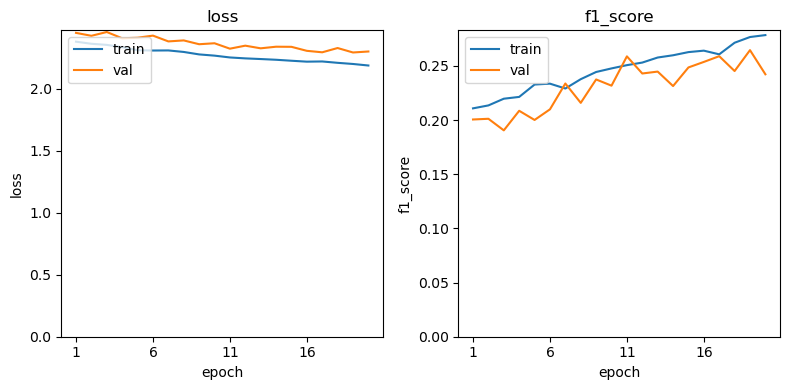

In [157]:
plot_model_history(Globalaveragepooling_Model_results2, ["loss", "f1_score"])

Even thought the model increased performance a bit and it is not overfitting. If we compare the score of validation of when we were using flatten, it is still higher than the one we got now.
Having this in mind, we want to increase performance while not overfitting the model.

In the next setp we will maintain Globalaveragepooling to control overfitting, but try to expand the network to see if we can increase performance

<a id="section-5"></a>

## **<font color='#ffffffff'> Base Model Extended with more Convolutions**
 <font>


We will add more convolutional blocks with the goal of increasing performance

In [158]:
class Extended_Conv_Model(Model):
    """
    Including two more Convolutional Blocks with more filters in order to improve performance

    """
    #Initialization
    def __init__(self):
        super().__init__(name="Extended_Conv_Model")

        self.n_classes = 23
        self.Rescaling = Rescaling(1./255)
        self.augmentation_layer = augmentation_moderate

        #First Convolutional Block
        self.Conv1 = Conv2D(
            filters=24,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_1"
        )

        #First Pooling Layer
        self.max_pool_layer_1 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_1"
        )


        #Second Convolutional Block
        self.Conv2 = Conv2D(
            filters=24,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_2"
        )

        #Second Pooling Layer
        self.max_pool_layer_2 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_2"
        )

        #Third Convolutional Block
        self.Conv3 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_3"
        )

        #Third Pooling Layer
        self.max_pool_layer_3 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_3"
        )


        #Fourth Convolutional Block
        self.Conv4 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_4"
        )

        #Fourth Pooling Layer
        self.max_pool_layer_4 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_4"
        )

        self.Globalaveragepooling_layer = GlobalAveragePooling2D()
        self.Dense_1 = Dense(100, activation="relu")
        self.Drop_out =Dropout(rate=0.2)
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)  
        x = self.augmentation_layer(x)
        x = self.Conv1(x)
        x = self.max_pool_layer_1(x)
        x = self.Conv2(x)
        x = self.max_pool_layer_2(x) 
        x = self.Conv3(x)
        x = self.max_pool_layer_3(x)
        x = self.Conv4(x)
        x = self.max_pool_layer_4(x)                              
        x = self.Globalaveragepooling_layer(x)                                     
        x = self.Dense_1(x)
        x = self.Drop_out(x)
        x = self.Dense_2(x)

        return x

In [159]:
Extended_Conv_Model = Extended_Conv_Model()
inputs = Input(shape=Input_shape)
_ = Extended_Conv_Model.call(inputs)
Extended_Conv_Model.summary()

Model: "Extended_Conv_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_22 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate           │ (None, 128, 128, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 126, 126, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ (None, 63, 63, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 61, 61, 24)     │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ (None, 30, 30, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_3 (Conv2D)           │ (None, 28, 28, 40)     │         8,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_3 (MaxPooling2D) │ (None, 14, 14, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_4 (Conv2D)           │ (None, 12, 12, 40)     │        14,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_4 (MaxPooling2D) │ (None, 6, 6, 40)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_15     │ (None, 40)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 100)            │         4,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,423 (138.37 KB)

 Trainable params: 35,423 (138.37 KB)

 Non-trainable params: 0 (0.00 B)

In [160]:
optimizer =Adam(learning_rate=0.001, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs = 40  # since the last model took 40 epochs to converge, we will use 40 in this one too

In [161]:
Extended_Conv_Model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [162]:
Extended_Conv_Model_results = Extended_Conv_Model.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.1548 - auc: 0.6856 - f1_score: 0.0888 - loss: 3.0039 - val_accuracy: 0.1391 - val_auc: 0.6767 - val_f1_score: 0.0285 - val_loss: 2.9527
Epoch 2/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.1745 - auc: 0.7116 - f1_score: 0.0756 - loss: 2.8287 - val_accuracy: 0.1836 - val_auc: 0.7298 - val_f1_score: 0.0792 - val_loss: 2.7783
Epoch 3/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.2166 - auc: 0.7557 - f1_score: 0.1101 - loss: 2.6874 - val_accuracy: 0.2056 - val_auc: 0.7530 - val_f1_score: 0.1052 - val_loss: 2.7238
Epoch 4/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.2363 - auc: 0.7780 - f1_score: 0.1357 - loss: 2.6055 - val_accuracy: 0.2371 - val_auc: 0.7777 - val_f1_score: 0.1487 - val_loss: 2.6086
Epoch 5/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.2505 - auc: 0.7944 - f1_score: 0.1495 - loss: 2.5395 - val_accuracy: 0.2411 - val_auc: 0.7923 - val_f1_score: 0.1498 - va

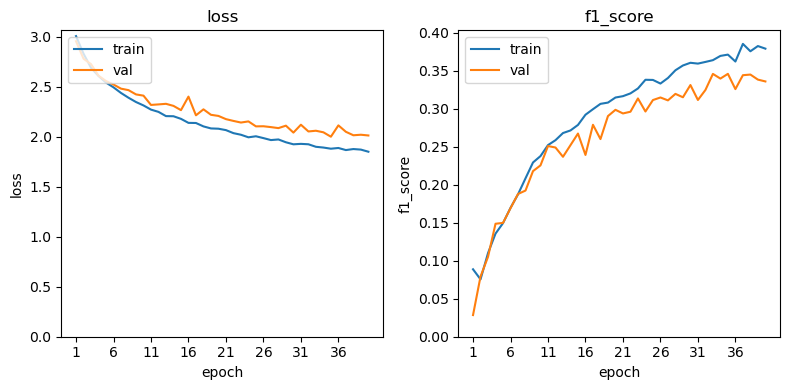

In [163]:

plot_model_history(Extended_Conv_Model_results, ["loss", "f1_score"])

We obtained better results in both F1 score and loss, and overfitting is well controlled. We will continue in this direction and believe the next step is to increase the number of filters in each convolutional layer. Since the dimensions of the final feature map are already 5 × 5, adding more convolutional layers would require changing the input image size. Therefore, for now, we will focus on experimenting with a higher number of filters.

### Adding More Filters to the Convolutions

In [164]:
class Extended_Conv_Model2(Model):
    """
    Experimenting more filters in each convolutional layer

    """
    #Initialization
    def __init__(self):
        super().__init__(name="Extended_Conv_Model2")

        self.n_classes = 23
        self.Rescaling = Rescaling(1./255)
        self.augmentation_layer = augmentation_moderate

        #First Convolutional Block
        self.Conv1 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_1"
        )

        #First Pooling Layer
        self.max_pool_layer_1 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_1"
        )


        #Second Convolutional Block
        self.Conv2 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_2"
        )

        #Second Pooling Layer
        self.max_pool_layer_2 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_2"
        )

        #Third Convolutional Block
        self.Conv3 = Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_3"
        )

        #Third Pooling Layer
        self.max_pool_layer_3 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_3"
        )


        #Fourth Convolutional Block
        self.Conv4 = Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_4"
        )

        #Fourth Pooling Layer
        self.max_pool_layer_4 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_4"
        )

        self.Globalaveragepooling_layer = GlobalAveragePooling2D()
        self.Dense_1 = Dense(100, activation="relu")
        self.Drop_out =Dropout(rate=0.2)
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)  
        x = self.augmentation_layer(x)
        x = self.Conv1(x)
        x = self.max_pool_layer_1(x)
        x = self.Conv2(x)
        x = self.max_pool_layer_2(x) 
        x = self.Conv3(x)
        x = self.max_pool_layer_3(x)
        x = self.Conv4(x)
        x = self.max_pool_layer_4(x)                              
        x = self.Globalaveragepooling_layer(x)                                     
        x = self.Dense_1(x)
        x = self.Drop_out(x)
        x = self.Dense_2(x)

        return x

In [165]:
Extended_Conv_Model2 = Extended_Conv_Model2()
inputs = Input(shape=Input_shape)
_ = Extended_Conv_Model2.call(inputs)
Extended_Conv_Model2.summary()

Model: "Extended_Conv_Model2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_23 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate           │ (None, 128, 128, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 126, 126, 40)   │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ (None, 63, 63, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 61, 61, 40)     │        14,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ (None, 30, 30, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_3 (Conv2D)           │ (None, 28, 28, 64)     │        23,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_3 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_4 (Conv2D)           │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_4 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_16     │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,415 (329.75 KB)

 Trainable params: 84,415 (329.75 KB)

 Non-trainable params: 0 (0.00 B)

In [166]:
optimizer =Adam(learning_rate=0.001, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs = 40  

In [167]:
Extended_Conv_Model2.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [168]:
Extended_Conv_Model2_results = Extended_Conv_Model2.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.1738 - auc: 0.7046 - f1_score: 0.1152 - loss: 2.9783 - val_accuracy: 0.1711 - val_auc: 0.6970 - val_f1_score: 0.0565 - val_loss: 2.8745
Epoch 2/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.1958 - auc: 0.7270 - f1_score: 0.0839 - loss: 2.7794 - val_accuracy: 0.1921 - val_auc: 0.7329 - val_f1_score: 0.0926 - val_loss: 2.7689
Epoch 3/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.2236 - auc: 0.7657 - f1_score: 0.1158 - loss: 2.6596 - val_accuracy: 0.2226 - val_auc: 0.7740 - val_f1_score: 0.1208 - val_loss: 2.6458
Epoch 4/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.2458 - auc: 0.7899 - f1_score: 0.1439 - loss: 2.5633 - val_accuracy: 0.2421 - val_auc: 0.7933 - val_f1_score: 0.1481 - val_loss: 2.5592
Epoch 5/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.2653 - auc: 0.8065 - f1_score: 0.1715 - loss: 2.4908 - val_accuracy: 0.2471 - val_auc: 0.7929 - val_f1_score: 0.1691 - va

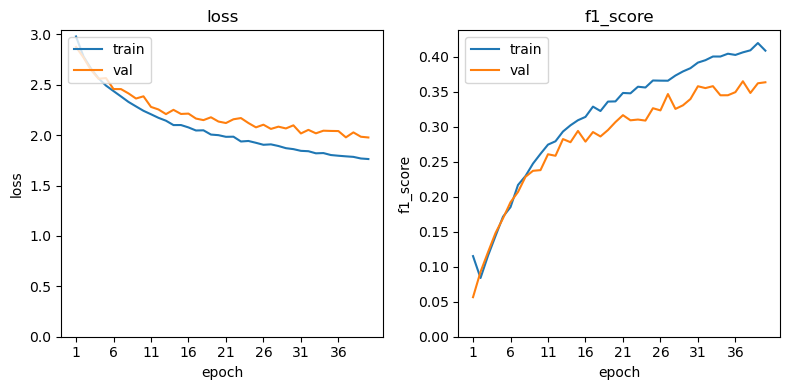

In [169]:

plot_model_history(Extended_Conv_Model2_results, ["loss", "f1_score"])

We continue to observe improvements in performance, and overfitting remains controlled. Next, we will add padding to the convolutional layers to better preserve and utilize information from the edges of the images, and evaluate its impact on performance.

### Extended Base Model with Padding 

In [170]:
class Extended_Conv_Model3(Model):
    """
    Adding Padding to the Convolutions to observe the impact on performance

    """
    #Initialization
    def __init__(self):
        super().__init__(name="Extended_Conv_Model3")

        self.n_classes = 23
        self.Rescaling = Rescaling(1./255)
        self.augmentation_layer = augmentation_moderate

        #First Convolutional Block
        self.Conv1 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            activation="relu",
            padding= "same",
            name="conv_layer_1"
        )

        #First Pooling Layer
        self.max_pool_layer_1 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_1"
        )


        #Second Convolutional Block
        self.Conv2 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            activation="relu",
            padding= "same",
            name="conv_layer_2"
        )

        #Second Pooling Layer
        self.max_pool_layer_2 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_2"
        )

        #Third Convolutional Block
        self.Conv3 = Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation="relu",
            padding= "same",
            name="conv_layer_3"
        )

        #Third Pooling Layer
        self.max_pool_layer_3 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_3"
        )


        #Fourth Convolutional Block
        self.Conv4 = Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation="relu",
            padding= "same",
            name="conv_layer_4"
        )

        #Fourth Pooling Layer
        self.max_pool_layer_4 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_4"
        )

        self.Globalaveragepooling_layer = GlobalAveragePooling2D()
        self.Dense_1 = Dense(100, activation="relu")
        self.Drop_out =Dropout(rate=0.2)
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)  
        x = self.augmentation_layer(x)
        x = self.Conv1(x)
        x = self.max_pool_layer_1(x)
        x = self.Conv2(x)
        x = self.max_pool_layer_2(x) 
        x = self.Conv3(x)
        x = self.max_pool_layer_3(x)
        x = self.Conv4(x)
        x = self.max_pool_layer_4(x)                              
        x = self.Globalaveragepooling_layer(x)                                     
        x = self.Dense_1(x)
        x = self.Drop_out(x)
        x = self.Dense_2(x)

        return x

In [171]:
Extended_Conv_Model3 = Extended_Conv_Model3()
inputs = Input(shape=Input_shape)
_ = Extended_Conv_Model3.call(inputs)
Extended_Conv_Model3.summary()

Model: "Extended_Conv_Model3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_24 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate           │ (None, 128, 128, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 128, 128, 40)   │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ (None, 64, 64, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 64, 64, 40)     │        14,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ (None, 32, 32, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_3 (Conv2D)           │ (None, 32, 32, 64)     │        23,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_3 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_4 (Conv2D)           │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_4 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_17     │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,415 (329.75 KB)

 Trainable params: 84,415 (329.75 KB)

 Non-trainable params: 0 (0.00 B)

In [172]:
optimizer =Adam(learning_rate=0.001, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs = 40  

In [173]:
Extended_Conv_Model3.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [174]:
Extended_Conv_Model3_results = Extended_Conv_Model3.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.1731 - auc: 0.6954 - f1_score: 0.1209 - loss: 3.0005 - val_accuracy: 0.1411 - val_auc: 0.6764 - val_f1_score: 0.0394 - val_loss: 2.9303
Epoch 2/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.1891 - auc: 0.7248 - f1_score: 0.0851 - loss: 2.7859 - val_accuracy: 0.2016 - val_auc: 0.7422 - val_f1_score: 0.1104 - val_loss: 2.7330
Epoch 3/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.2229 - auc: 0.7622 - f1_score: 0.1246 - loss: 2.6676 - val_accuracy: 0.2181 - val_auc: 0.7747 - val_f1_score: 0.1303 - val_loss: 2.6329
Epoch 4/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.2467 - auc: 0.7886 - f1_score: 0.1550 - loss: 2.5656 - val_accuracy: 0.2446 - val_auc: 0.7879 - val_f1_score: 0.1604 - val_loss: 2.5833
Epoch 5/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.2650 - auc: 0.8050 - f1_score: 0.1786 - loss: 2.4927 - val_accuracy: 0.2511 - val_auc: 0.8033 - val_f1_score: 0.1684 - v

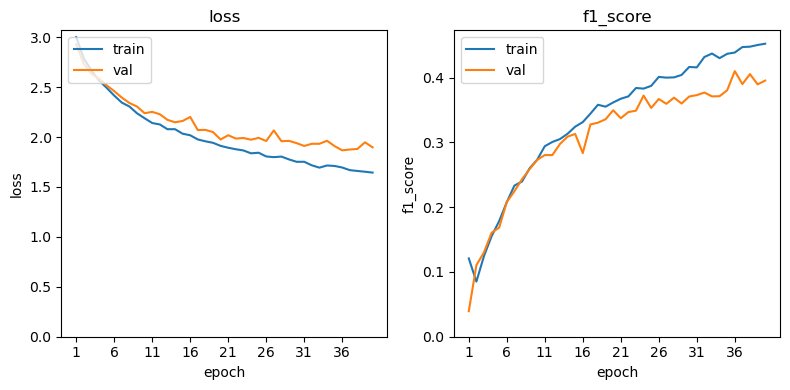

In [175]:

plot_model_history(Extended_Conv_Model3_results, ["loss", "f1_score"])

With padding the results improve a little compared to without padding, so it's something to consider keeping.

After some research we saw the use of batch normalization layers in convolutional blocks to improve gradient flow, so we will try it, to observe the effects in the metrics

<a id="section-6"></a>

## **<font color='#ffffffff'> Base Model  with Batch Normalization**
 <font>


In [176]:
class BatchNormalization_Model(Model):
    """
    Adding Batch Normalization Layers 

    """
    #Initialization
    def __init__(self):
        super().__init__(name="BatchNormalization_Model")

        self.n_classes = 23
        self.Rescaling = Rescaling(1./255)
        self.augmentation_layer = augmentation_moderate

        #First Convolutional Block
        self.Conv1 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            activation="relu",
            padding= "same",
            name="conv_layer_1"
        )

        self.BatchNormalization_layer1 = BatchNormalization()

        #First Pooling Layer
        self.max_pool_layer_1 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_1"
        )


        #Second Convolutional Block
        self.Conv2 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            activation="relu",
            padding= "same",
            name="conv_layer_2"
        )

        self.BatchNormalization_layer2 = BatchNormalization()

        #Second Pooling Layer
        self.max_pool_layer_2 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_2"
        )

        #Third Convolutional Block
        self.Conv3 = Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation="relu",
            padding= "same",
            name="conv_layer_3"
        )

        self.BatchNormalization_layer3 = BatchNormalization()

        #Third Pooling Layer
        self.max_pool_layer_3 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_3"
        )


        #Fourth Convolutional Block
        self.Conv4 = Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation="relu",
            padding= "same",
            name="conv_layer_4"
        )

        self.BatchNormalization_layer4 = BatchNormalization()

        #Fourth Pooling Layer
        self.max_pool_layer_4 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_4"
        )

        self.Globalaveragepooling_layer = GlobalAveragePooling2D()
        self.Dense_1 = Dense(100, activation="relu")
        self.Drop_out =Dropout(rate=0.2)
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)  
        x = self.augmentation_layer(x)
        x = self.Conv1(x)
        x = self.BatchNormalization_layer1(x)
        x = self.max_pool_layer_1(x)
        x = self.Conv2(x)
        x = self.BatchNormalization_layer2(x)
        x = self.max_pool_layer_2(x) 
        x = self.Conv3(x)
        x = self.BatchNormalization_layer3(x)
        x = self.max_pool_layer_3(x)
        x = self.Conv4(x)
        x = self.BatchNormalization_layer4(x)
        x = self.max_pool_layer_4(x)                              
        x = self.Globalaveragepooling_layer(x)                                     
        x = self.Dense_1(x)
        x = self.Drop_out(x)
        x = self.Dense_2(x)

        return x

In [177]:
BatchNormalization_Model = BatchNormalization_Model()
inputs = Input(shape=Input_shape)
_ = BatchNormalization_Model.call(inputs)
BatchNormalization_Model.summary()

Model: "BatchNormalization_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_25 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate           │ (None, 128, 128, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 128, 128, 40)   │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 128, 128, 40)   │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ (None, 64, 64, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 64, 64, 40)     │        14,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 64, 64, 40)     │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ (None, 32, 32, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_3 (Conv2D)           │ (None, 32, 32, 64)     │        23,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_3 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_4 (Conv2D)           │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_4 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_18     │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,247 (333.00 KB)

 Trainable params: 84,831 (331.37 KB)

 Non-trainable params: 416 (1.62 KB)

In [178]:
optimizer =Adam(learning_rate=0.001, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs = 40  

In [179]:
BatchNormalization_Model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [180]:
BatchNormalization_Model_results = BatchNormalization_Model.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - accuracy: 0.2751 - auc: 0.7992 - f1_score: 0.2140 - loss: 2.6210 - val_accuracy: 0.2861 - val_auc: 0.8100 - val_f1_score: 0.2170 - val_loss: 2.4619
Epoch 2/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.3142 - auc: 0.8397 - f1_score: 0.2493 - loss: 2.3156 - val_accuracy: 0.3337 - val_auc: 0.8504 - val_f1_score: 0.2646 - val_loss: 2.2572
Epoch 3/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.3513 - auc: 0.8624 - f1_score: 0.2935 - loss: 2.1754 - val_accuracy: 0.3522 - val_auc: 0.8581 - val_f1_score: 0.2898 - val_loss: 2.2013
Epoch 4/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.3742 - auc: 0.8777 - f1_score: 0.3182 - loss: 2.0734 - val_accuracy: 0.3682 - val_auc: 0.8709 - val_f1_score: 0.3082 - val_loss: 2.1215
Epoch 5/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.3998 - auc: 0.8869 - f1_score: 0.3439 - loss: 1.9986 - val_accuracy: 0.3912 - val_auc: 0.8818 - val_f1_score: 0.3306

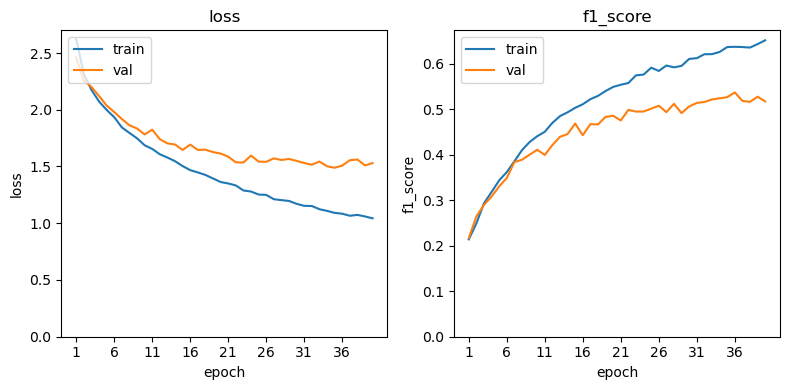

In [181]:

plot_model_history(BatchNormalization_Model_results, ["loss", "f1_score"])

Based on the results, we can see that the scores improved considerably. Overfitting increased slightly, but not dramatically.

We believe we have already reached a good solution for a model built from scratch, so next we will try new approaches to see how the model’s performance responds.

### Adding the Batch normalization layer before the activation function

After some research we discovered that the batch normalization layers should be added before the activation function and not after, so we decided to try it out

In [182]:
@keras.saving.register_keras_serializable()
class BatchNormalization2_Model(Model):
    """
    Adding Batch Normalization Layers (before activation function)

    """
    #Initialization
    def __init__(self, **kwargs):
        super().__init__(name="BatchNormalization_Model2")

        self.n_classes = 23
        self.Rescaling = Rescaling(1./255)
        self.augmentation_layer = augmentation_moderate

        #First Convolutional Block
        self.Conv1 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            padding= "same",
            name="conv_layer_1"
        )

        self.BatchNormalization_layer1 = BatchNormalization()

        self.activation_1 = Activation(activation="relu")

        #First Pooling Layer
        self.max_pool_layer_1 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_1"
        )


        #Second Convolutional Block
        self.Conv2 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            padding= "same",
            name="conv_layer_2"
        )

        self.BatchNormalization_layer2 = BatchNormalization()

        self.activation_2 = Activation(activation="relu")

        #Second Pooling Layer
        self.max_pool_layer_2 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_2"
        )

        #Third Convolutional Block
        self.Conv3 = Conv2D(
            filters=64,
            kernel_size=(3, 3),
            padding= "same",
            name="conv_layer_3"
        )

        self.BatchNormalization_layer3 = BatchNormalization()

        self.activation_3 = Activation(activation="relu")

        #Third Pooling Layer
        self.max_pool_layer_3 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_3"
        )


        #Fourth Convolutional Block
        self.Conv4 = Conv2D(
            filters=64,
            kernel_size=(3, 3),
            padding= "same",
            name="conv_layer_4"
        )

        self.BatchNormalization_layer4 = BatchNormalization()

        self.activation_4 = Activation(activation="relu")

        #Fourth Pooling Layer
        self.max_pool_layer_4 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_4"
        )

        self.Globalaveragepooling_layer = GlobalAveragePooling2D()
        self.Dense_1 = Dense(100, activation="relu")
        self.Drop_out =Dropout(rate=0.2)
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, inputs):

        x = inputs

        x = self.Rescaling(x)

        
        x = self.augmentation_layer(x)

        x = self.Conv1(x)
        x = self.BatchNormalization_layer1(x)
        x = self.activation_1(x)
        x = self.max_pool_layer_1(x)

        x = self.Conv2(x)
        x = self.BatchNormalization_layer2(x)
        x = self.activation_2(x)
        x = self.max_pool_layer_2(x)

        x = self.Conv3(x)
        x = self.BatchNormalization_layer3(x)
        x = self.activation_3(x)
        x = self.max_pool_layer_3(x)

        x = self.Conv4(x)
        x = self.BatchNormalization_layer4(x)
        x = self.activation_4(x)
        x = self.max_pool_layer_4(x)

        x = self.Globalaveragepooling_layer(x)
        x = self.Dense_1(x)
        x = self.Drop_out(x)
        x = self.Dense_2(x)

        return x

In [183]:
BatchNormalization_Model_2 = BatchNormalization2_Model()
inputs = Input(shape=Input_shape)
_ = BatchNormalization_Model_2.call(inputs)
BatchNormalization_Model_2.summary()

Model: "BatchNormalization_Model2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_26 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate           │ (None, 128, 128, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 128, 128, 40)   │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 128, 128, 40)   │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_36 (Activation)      │ (None, 128, 128, 40)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ (None, 64, 64, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 64, 64, 40)     │        14,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 64, 64, 40)     │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_37 (Activation)      │ (None, 64, 64, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ (None, 32, 32, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_3 (Conv2D)           │ (None, 32, 32, 64)     │        23,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_38 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_3 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_4 (Conv2D)           │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_39 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_4 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_19     │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 23)             │         2,32

 Total params: 85,247 (333.00 KB)

 Trainable params: 84,831 (331.37 KB)

 Non-trainable params: 416 (1.62 KB)

In [184]:
optimizer =Adam(learning_rate=0.001, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs = 40  

In [185]:
BatchNormalization_Model_2.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [186]:
BatchNormalization2_Model_results = BatchNormalization_Model_2.fit(
    train_df,
    validation_data= val_df,
    epochs=epochs
)

Epoch 1/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 14s 79ms/step - accuracy: 0.2818 - auc: 0.7988 - f1_score: 0.2173 - loss: 2.6769 - val_accuracy: 0.2521 - val_auc: 0.7989 - val_f1_score: 0.1747 - val_loss: 2.5335
Epoch 2/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.2946 - auc: 0.8298 - f1_score: 0.2157 - loss: 2.3721 - val_accuracy: 0.2966 - val_auc: 0.8347 - val_f1_score: 0.2184 - val_loss: 2.3506
Epoch 3/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accuracy: 0.3362 - auc: 0.8558 - f1_score: 0.2683 - loss: 2.2231 - val_accuracy: 0.3327 - val_auc: 0.8479 - val_f1_score: 0.2676 - val_loss: 2.2699
Epoch 4/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.3699 - auc: 0.8718 - f1_score: 0.3081 - loss: 2.1132 - val_accuracy: 0.3402 - val_auc: 0.8669 - val_f1_score: 0.2812 - val_loss: 2.1698
Epoch 5/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.3887 - auc: 0.8825 - f1_score: 0.3283 - loss: 2.0382 - val_accuracy: 0.3662 - val_auc: 0.8753 - val_f1_score: 0.3061

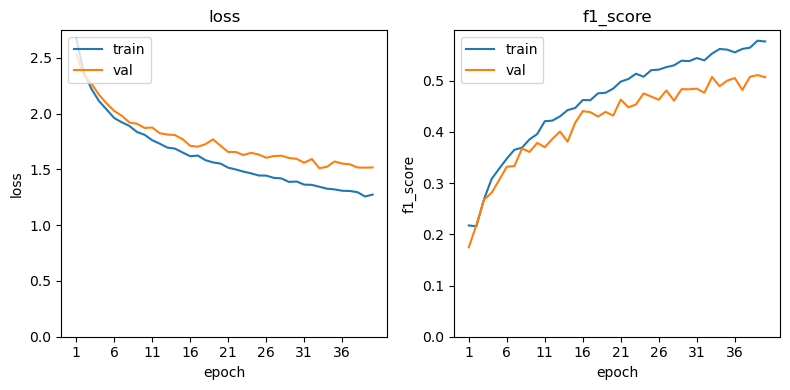

In [187]:

plot_model_history(BatchNormalization2_Model_results, ["loss", "f1_score"])


After testing batch normalization layers before the activation functions, the results were not significantly different. The validation F1 score reached 0.5, similar to the previous model where batch normalization was applied after the activation function. However, the training F1 score in this model was 0.57, compared to 0.64 in the previous one, indicating less overfitting. Based on this and the fact and that it is theoretically more appropriate, we will keep the batch normalization layers before the activation functions.

In [188]:
#This model became the best one from the models built from scratch so we saved it
#BatchNormalization_Model_2.save('Base_Model.keras')

<a id="section-7"></a>

## **<font color='#ffffffff'> Base Model with Deeper Classification Head**
 <font>


Since in a previous step we extended the convolutional part of our network to improve performance, we will now focus on improving the classifier to observe its impact on overall performance. We expect some increase in overfitting, so to account for that we will increase dropout rate to 0.4

In [189]:
class Extra_Dense_Model(Model):
    """
    Expanding the Classification Head

    """
    #Initialization
    def __init__(self):
        super().__init__(name="Extra_Dense_Model")

        self.n_classes = 23
        self.Rescaling = Rescaling(1./255)
        self.augmentation_layer = augmentation_moderate

        #First Convolutional Block
        self.Conv1 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            padding= "same",
            name="conv_layer_1"
        )

        self.BatchNormalization_layer1 = BatchNormalization()

        self.activation_1 = Activation(activation="relu")

        #First Pooling Layer
        self.max_pool_layer_1 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_1"
        )


        #Second Convolutional Block
        self.Conv2 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            padding= "same",
            name="conv_layer_2"
        )

        self.BatchNormalization_layer2 = BatchNormalization()

        self.activation_2 = Activation(activation="relu")

        #Second Pooling Layer
        self.max_pool_layer_2 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_2"
        )

        #Third Convolutional Block
        self.Conv3 = Conv2D(
            filters=64,
            kernel_size=(3, 3),
            padding= "same",
            name="conv_layer_3"
        )

        self.BatchNormalization_layer3 = BatchNormalization()

        self.activation_3 = Activation(activation="relu")

        #Third Pooling Layer
        self.max_pool_layer_3 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_3"
        )


        #Fourth Convolutional Block
        self.Conv4 = Conv2D(
            filters=64,
            kernel_size=(3, 3),
            padding= "same",
            name="conv_layer_4"
        )

        self.BatchNormalization_layer4 = BatchNormalization()

        self.activation_4 = Activation(activation="relu")

        #Fourth Pooling Layer
        self.max_pool_layer_4 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_4"
        )

        self.Globalaveragepooling_layer = GlobalAveragePooling2D()
        self.Dense_1 = Dense(258, activation="relu")
        self.Drop_out =Dropout(rate=0.4)  #Higher drop out to control overfitting
        self.Dense_2 = Dense(100, activation="relu")
        self.Dense_3 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)  
        x = self.augmentation_layer(x)
        x = self.Conv1(x)
        x = self.BatchNormalization_layer1(x)
        x = self.activation_1(x)
        x = self.max_pool_layer_1(x)
        x = self.Conv2(x)
        x = self.BatchNormalization_layer2(x)
        x = self.activation_2(x)
        x = self.max_pool_layer_2(x) 
        x = self.Conv3(x)
        x = self.BatchNormalization_layer3(x)
        x = self.activation_3(x)
        x = self.max_pool_layer_3(x)
        x = self.Conv4(x)
        x = self.BatchNormalization_layer4(x)
        x = self.activation_4(x)
        x = self.max_pool_layer_4(x)                                
        x = self.Globalaveragepooling_layer(x)                                     
        x = self.Dense_1(x)
        x = self.Drop_out(x)
        x = self.Dense_2(x)
        x = self.Dense_3(x)

        return x

In [190]:
Extra_Dense_Model = Extra_Dense_Model()
inputs = Input(shape=Input_shape)
_ = Extra_Dense_Model.call(inputs)
Extra_Dense_Model.summary()

Model: "Extra_Dense_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_27 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate           │ (None, 128, 128, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 128, 128, 40)   │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 128, 128, 40)   │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_40 (Activation)      │ (None, 128, 128, 40)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ (None, 64, 64, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 64, 64, 40)     │        14,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 64, 64, 40)     │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_41 (Activation)      │ (None, 64, 64, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ (None, 32, 32, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_3 (Conv2D)           │ (None, 32, 32, 64)     │        23,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_42 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_3 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_4 (Conv2D)           │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_43 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_4 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_20     │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 258)            │        16,770 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 258)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 100)            │        25,90

 Total params: 121,417 (474.29 KB)

 Trainable params: 121,001 (472.66 KB)

 Non-trainable params: 416 (1.62 KB)

In [191]:
optimizer =Adam(learning_rate=0.001, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs = 40  

In [192]:
Extra_Dense_Model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [193]:
Extra_Dense_Model_results = Extra_Dense_Model.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.2730 - auc: 0.7965 - f1_score: 0.2142 - loss: 2.6906 - val_accuracy: 0.2431 - val_auc: 0.7894 - val_f1_score: 0.1649 - val_loss: 2.5646
Epoch 2/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.2861 - auc: 0.8249 - f1_score: 0.2046 - loss: 2.3998 - val_accuracy: 0.3012 - val_auc: 0.8286 - val_f1_score: 0.2266 - val_loss: 2.3741
Epoch 3/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - accuracy: 0.3281 - auc: 0.8509 - f1_score: 0.2598 - loss: 2.2487 - val_accuracy: 0.3257 - val_auc: 0.8517 - val_f1_score: 0.2525 - val_loss: 2.2511
Epoch 4/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.3576 - auc: 0.8655 - f1_score: 0.2927 - loss: 2.1556 - val_accuracy: 0.3412 - val_auc: 0.8653 - val_f1_score: 0.2831 - val_loss: 2.1687
Epoch 5/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.3706 - auc: 0.8767 - f1_score: 0.3122 - loss: 2.0790 - val_accuracy: 0.3722 - val_auc: 0.8706 - val_f1_score: 0.3041

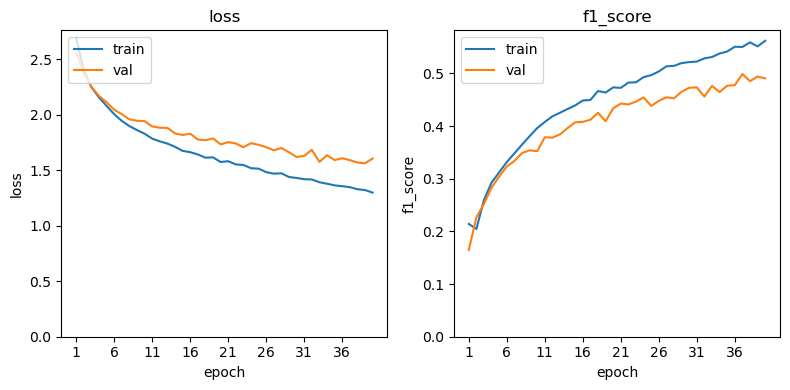

In [194]:


plot_model_history(Extra_Dense_Model_results, ["loss", "f1_score"])



The results were very similar to those obtained without the extended classification head (practically identical). Therefore, we conclude that it is not worth adding more dense layers, as this increases computational cost and requires a higher dropout rate to control overfitting.

We conclude that the best model was the one with the batch normalization layers before the activation function, since it gave us a good score for a model built from scratch and was not overfitting a lot

In [195]:
#This model became the best one from the models built from scratch so we saved it
#BatchNormalization2_Model.save('Base_Model.keras')

<a id="section-8"></a>

## **<font color='#ffffffff'> Experimenting different image sizes**
 <font>



Now since we discovered a competent model, we will test different image sizes to observe the difference between them

### Image 256 x 256

In [212]:
train_df_256 = image_dataset_from_directory(
    Train_Path,
    label_mode="categorical",
    interpolation="bilinear",
    image_size= (256,256),
    batch_size=Batch_size,
    seed=42
)

Found 9329 files belonging to 23 classes.


In [213]:
val_df_256 = image_dataset_from_directory(
    Validation_Path,
    label_mode="categorical",
    interpolation="bilinear",
    image_size= (256,256),
    batch_size=Batch_size,
    seed=42,
)

Found 1999 files belonging to 23 classes.


In [214]:
Input_shape = (256,256,3)

In [215]:
model_256 = BatchNormalization2_Model()
inputs = Input(shape=Input_shape)
_ = model_256.call(inputs)
model_256.summary()


Model: "BatchNormalization_Model2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_30 (Rescaling)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate           │ (None, 256, 256, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 256, 256, 40)   │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 256, 256, 40)   │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_52 (Activation)      │ (None, 256, 256, 40)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ (None, 128, 128, 40)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 128, 128, 40)   │        14,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 128, 128, 40)   │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_53 (Activation)      │ (None, 128, 128, 40)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ (None, 64, 64, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_3 (Conv2D)           │ (None, 64, 64, 64)     │        23,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_62          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_54 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_3 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_4 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_63          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_55 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_4 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_23     │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 23)             │         2,32

 Total params: 85,247 (333.00 KB)

 Trainable params: 84,831 (331.37 KB)

 Non-trainable params: 416 (1.62 KB)

In [216]:
optimizer =Adam(learning_rate=0.001, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs = 40  

In [217]:
model_256.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [218]:
model_256_results = model_256.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.2445 - auc: 0.7774 - f1_score: 0.1665 - loss: 2.6797 - val_accuracy: 0.2596 - val_auc: 0.7965 - val_f1_score: 0.1827 - val_loss: 2.5315
Epoch 2/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.2995 - auc: 0.8326 - f1_score: 0.2262 - loss: 2.3601 - val_accuracy: 0.3067 - val_auc: 0.8404 - val_f1_score: 0.2389 - val_loss: 2.3307
Epoch 3/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.3370 - auc: 0.8585 - f1_score: 0.2708 - loss: 2.2101 - val_accuracy: 0.3282 - val_auc: 0.8545 - val_f1_score: 0.2634 - val_loss: 2.2420
Epoch 4/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - accuracy: 0.3687 - auc: 0.8739 - f1_score: 0.3099 - loss: 2.1032 - val_accuracy: 0.3592 - val_auc: 0.8707 - val_f1_score: 0.2964 - val_loss: 2.1323
Epoch 5/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.3949 - auc: 0.8845 - f1_score: 0.3379 - loss: 2.0217 - val_accuracy: 0.3682 - val_auc: 0.8742 - val_f1_score: 0.3038

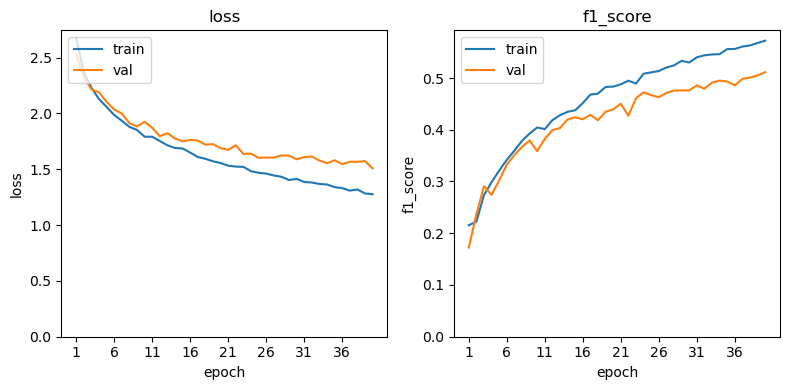

In [203]:
plot_model_history(model_256_results, ["loss", "f1_score"])

### image 512 x 512

In [222]:
train_df_512 = image_dataset_from_directory(
    Train_Path,
    label_mode="categorical",
    interpolation="bilinear",
    image_size= (512,512),
    batch_size=16,
    seed=42
)

Found 9329 files belonging to 23 classes.


In [223]:
val_df_512 = image_dataset_from_directory(
    Validation_Path,
    label_mode="categorical",
    interpolation="bilinear",
    image_size= (512,512),
    batch_size=16,
    seed=42,
)

Found 1999 files belonging to 23 classes.


In [224]:
Input_shape = (512,512,3)

In [225]:
model_512 = BatchNormalization2_Model()
inputs = Input(shape=Input_shape)
_ = model_512.call(inputs)
model_512.summary()

Model: "BatchNormalization_Model2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_31 (Rescaling)        │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate           │ (None, 512, 512, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 512, 512, 40)   │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 512, 512, 40)   │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_56 (Activation)      │ (None, 512, 512, 40)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ (None, 256, 256, 40)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 256, 256, 40)   │        14,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 256, 256, 40)   │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_57 (Activation)      │ (None, 256, 256, 40)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ (None, 128, 128, 40)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_3 (Conv2D)           │ (None, 128, 128, 64)   │        23,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_66          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_58 (Activation)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_3 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_4 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_67          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_59 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_4 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_24     │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 23)             │         2,32

 Total params: 85,247 (333.00 KB)

 Trainable params: 84,831 (331.37 KB)

 Non-trainable params: 416 (1.62 KB)

In [226]:
optimizer =Adam(learning_rate=0.001, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs = 20

In [227]:
model_512.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [228]:
model_512_results = model_512.fit(
    train_df_512,
    validation_data=val_df_512,
    epochs= 20 #We are testing just 20 epochs because 40 would take to much time
)

Epoch 1/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 141s 237ms/step - accuracy: 0.2115 - auc: 0.7310 - f1_score: 0.1426 - loss: 2.6711 - val_accuracy: 0.2406 - val_auc: 0.7916 - val_f1_score: 0.1564 - val_loss: 2.5564
Epoch 2/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 139s 238ms/step - accuracy: 0.2881 - auc: 0.8260 - f1_score: 0.2090 - loss: 2.3922 - val_accuracy: 0.3047 - val_auc: 0.8339 - val_f1_score: 0.2216 - val_loss: 2.3485
Epoch 3/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 139s 239ms/step - accuracy: 0.3287 - auc: 0.8501 - f1_score: 0.2557 - loss: 2.2563 - val_accuracy: 0.3247 - val_auc: 0.8520 - val_f1_score: 0.2478 - val_loss: 2.2488
Epoch 4/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 139s 238ms/step - accuracy: 0.3561 - auc: 0.8658 - f1_score: 0.2880 - loss: 2.1548 - val_accuracy: 0.3512 - val_auc: 0.8661 - val_f1_score: 0.2857 - val_loss: 2.1661
Epoch 5/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 139s 238ms/step - accuracy: 0.3831 - auc: 0.8789 - f1_score: 0.3211 - loss: 2.0629 - val_accuracy: 0.3557 - val_auc: 0.8690 - val_f1_sco

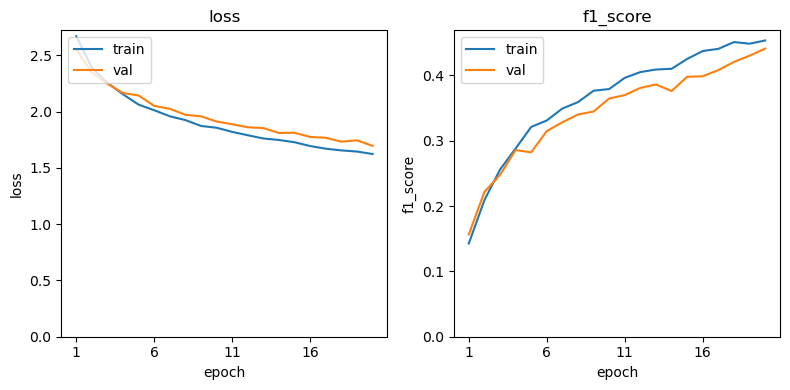

In [229]:
plot_model_history(model_512_results, ["loss", "f1_score"])

After analyzing the performance of our base model with different image sizes, we can conclude that increasing the image size does not significantly improve performance. The model with an image size of 128 × 128 achieved an F1 score of 0.57 on training and 0.50 on validation, while the model with 256 × 256 achieved the same results. The model with 512 × 512 obtained a slightly lower training F1 score of 0.54 and the same validation score of 0.50, indicating slightly less overfitting. However, this is a minor difference, so we don't believe it is relevant.

<a id="section-9"></a>

## **<font color='#ffffffff'> Conclusion**
 <font>



To conclude this notebook, we believe we achieved solid performance with a model built from scratch and trained solely on our dataset. This process helped us understand what factors contribute to improving a general model, as well as how the underlying components of a neural network operate. Our best model achieved an F1 score of 0.54 on the training set and 0.50 on the validation set. We will evaluate its performance on the test dataset in a separate evaluation notebook.